c:\Users\junkim\MyProjects\mlflow_wine\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


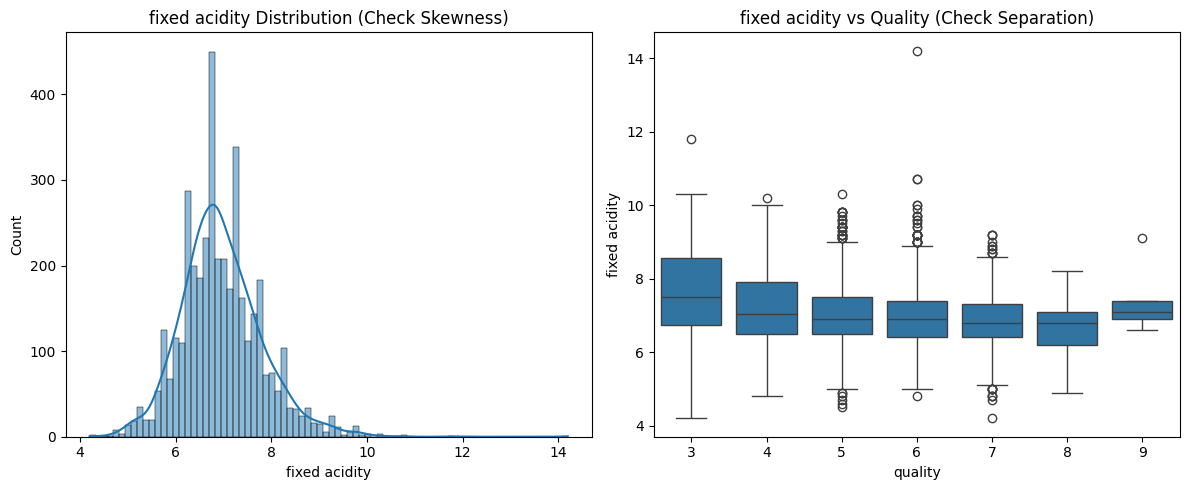

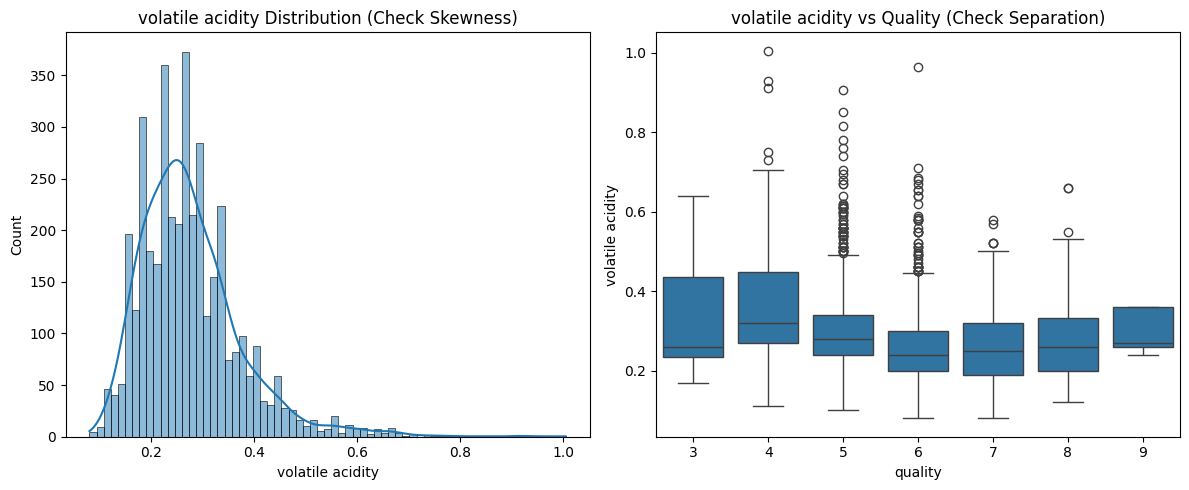

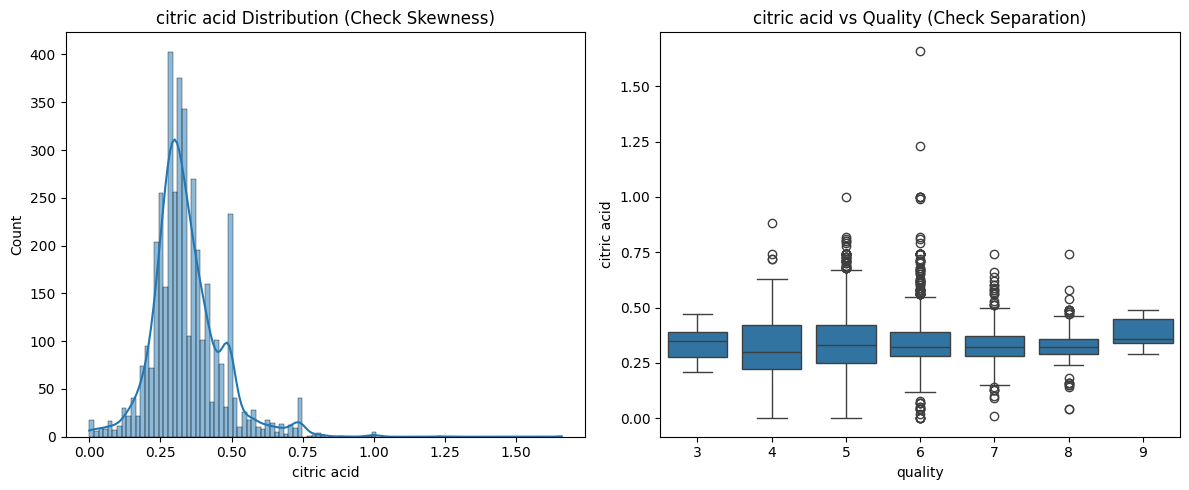

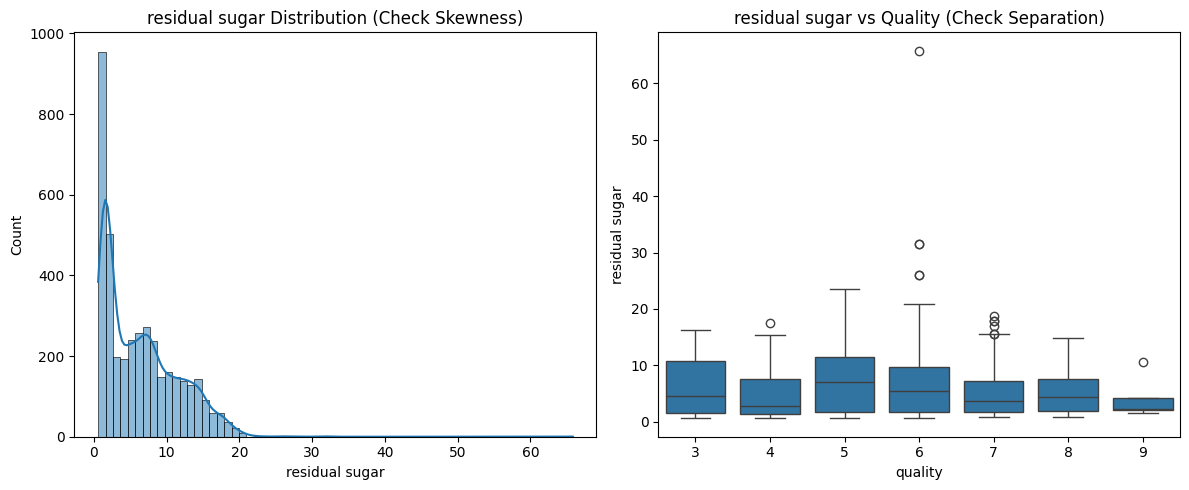

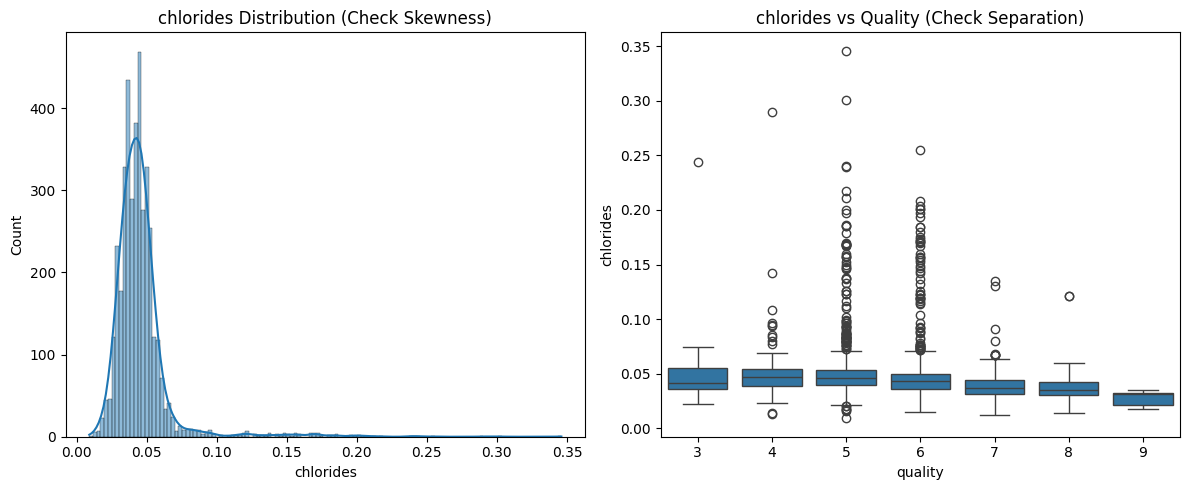

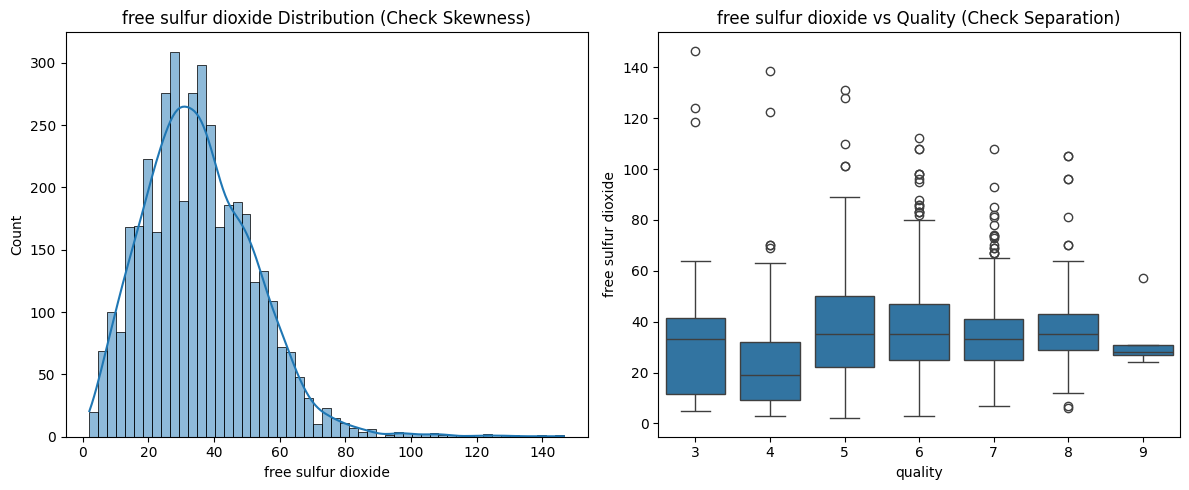

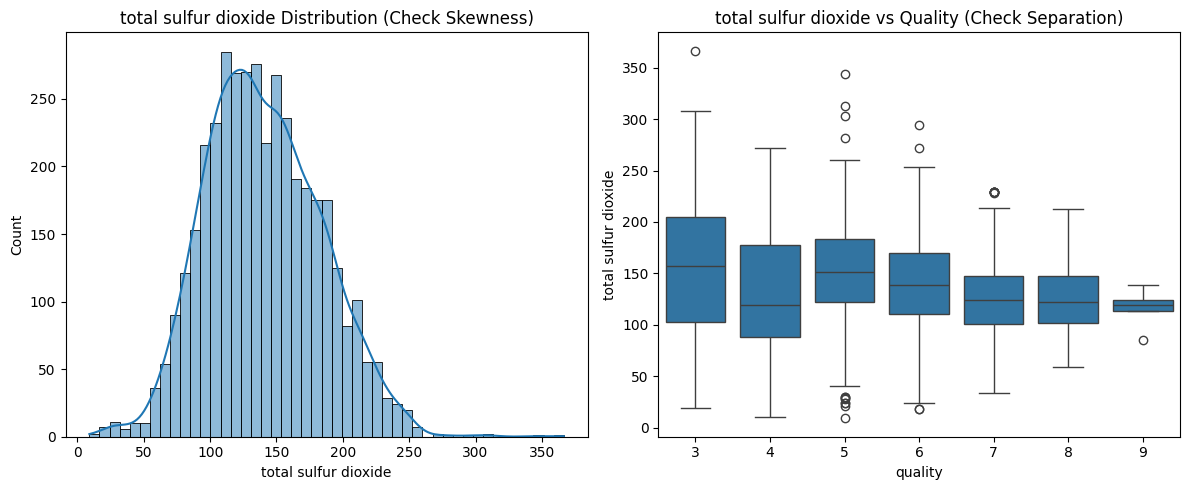

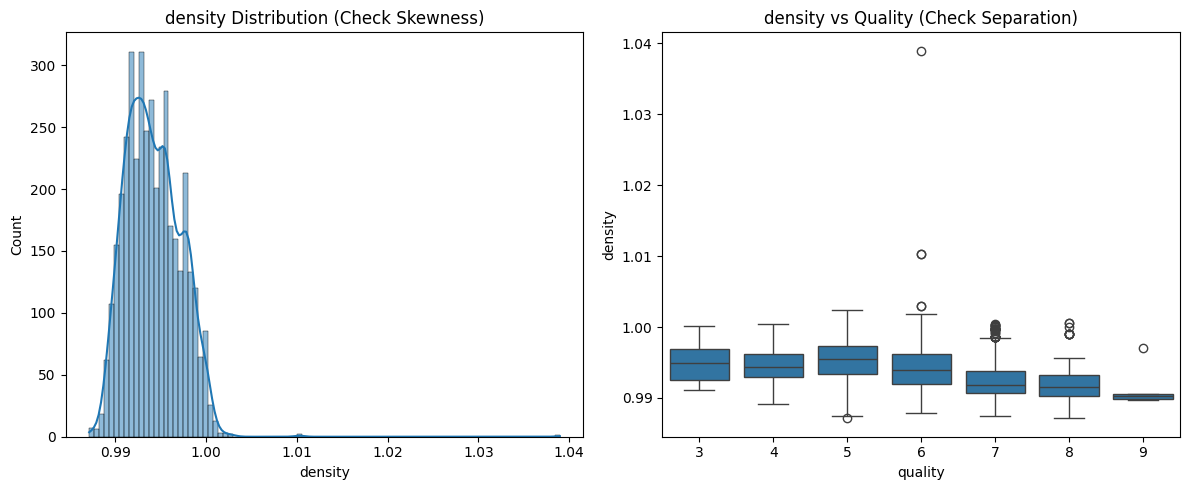

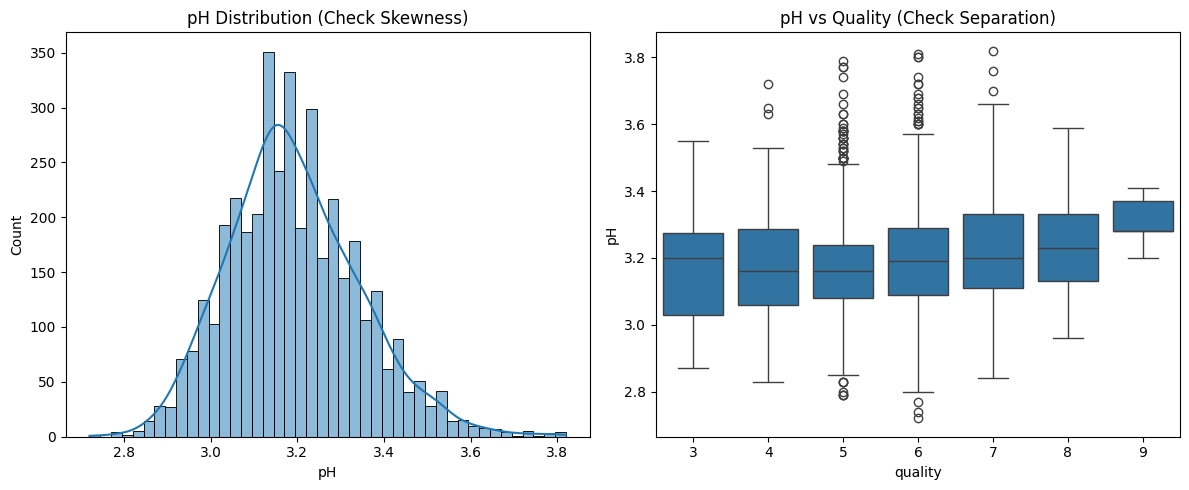

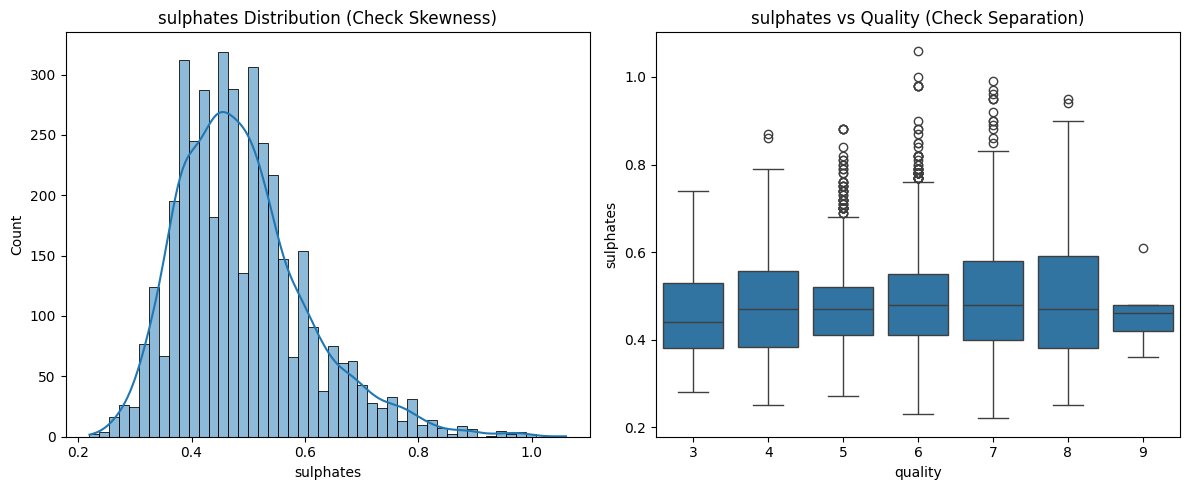

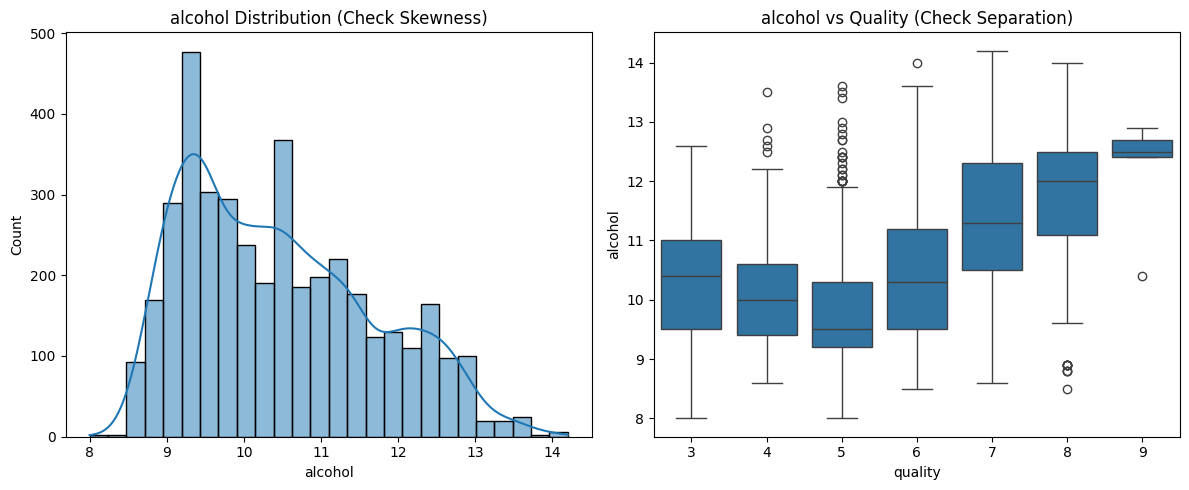

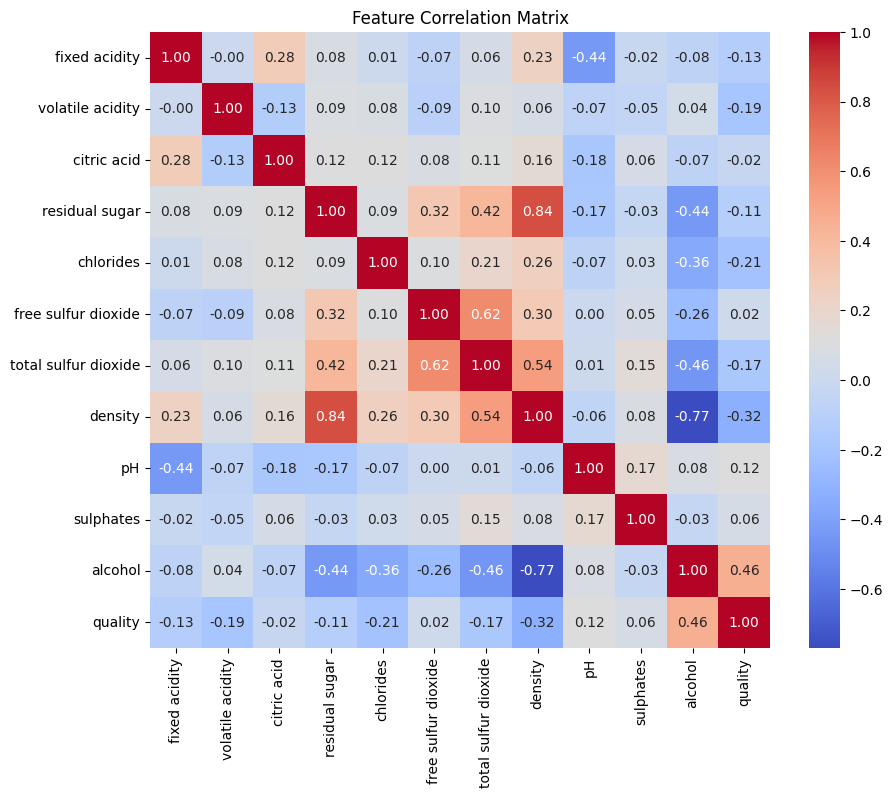

Removed 80 outliers.


c:\Users\junkim\MyProjects\mlflow_wine\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///c:/Users/junkim/MyProjects/mlflow_wine/mlruns/253741538419345772', creation_time=1764317395030, experiment_id='253741538419345772', last_update_time=1764317395030, lifecycle_stage='active', name='Wine_Quality_Optimization', tags={}>

In [1]:
# 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import shap
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.linear_model import ElasticNet
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, f1_score, cohen_kappa_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# 1. 데이터 로드 및 인덱스 제거
# 인덱스 열(0번 컬럼)을 제거하여 모델이 행 번호를 학습하는 것을 방지함.
df_train = pd.read_csv('wine_data_homework.csv', index_col=0)

# 2. 고급 EDA 및 통계적 시각화
# 각 변수의 분포와 품질과의 관계를 시각화하여 데이터의 특성을 파악.
def perform_eda(df):
    for col in df.columns[:-1]:
        plt.figure(figsize=(12, 5))
        
        # 히스토그램 & KDE: 데이터의 왜도(Skewness)와 분포 형태 확인
        plt.subplot(1, 2, 1)
        sns.histplot(df[col], kde=True)
        plt.title(f'{col} Distribution (Check Skewness)')
        
        # 박스플롯: 품질 등급별 변수의 중앙값 차이 및 이상치 확인
        plt.subplot(1, 2, 2)
        sns.boxplot(x='quality', y=col, data=df)
        plt.title(f'{col} vs Quality (Check Separation)')
        
        plt.tight_layout()
        plt.show() # MLflow에 아티팩트로 저장 가능

    # 상관관계 히트맵: 다중공선성(Multicollinearity) 확인 (예: Density와 Alcohol)
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Feature Correlation Matrix')
    plt.show()

perform_eda(df_train)

# 3. 이상치 탐지 (Isolation Forest)
# 다변량 이상치를 탐지하기 위해 Isolation Forest 사용.
# contamination=0.02는 전체 데이터의 2%를 이상치로 간주하여 제거함을 의미.
iso = IsolationForest(contamination=0.02, random_state=42)
yhat = iso.fit_predict(df_train.drop('quality', axis=1))
mask = yhat!= -1
df_clean = df_train[mask]
print(f"Removed {len(df_train) - len(df_clean)} outliers.")

# 4. 도메인 지식 기반 피처 엔지니어링
def feature_engineering(df):
    data = df.copy()
    # 분자 SO2: pH에 따른 유효 이산화황 농도 계산 (항균력 지표)
    data['molecular_so2'] = data['free sulfur dioxide'] / (1 + 10**(data['pH'] - 1.81))
    
    # 결합 SO2: 총량에서 유리형을 뺀 값 (산화 이력 지표)
    data['bound_so2'] = data['total sulfur dioxide'] - data['free sulfur dioxide']
    
    # 휘발성 산도 비율: 전체 산도 중 결함 원인인 휘발성 산도의 비중
    data['total_acidity'] = data['fixed acidity'] + data['volatile acidity']
    data['volatile_ratio'] = data['volatile acidity'] / data['total_acidity']
    
    # 알코올-밀도 상호작용: 와인의 바디감(Body)을 나타내는 지표
    data['alcohol_density'] = data['alcohol'] * data['density']
    return data

df_eng = feature_engineering(df_clean)

# 5. 전처리 파이프라인 및 모델 학습 (MLflow)
# 학습/검증 데이터 분리 (Stratify 옵션으로 클래스 비율 유지)
X = df_eng.drop('quality', axis=1)
y = df_eng['quality']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# MLflow 실험 설정
# mlflow.set_tracking_uri("file:///home/user/.mlflow") # Ajoupyterhub 경로 설정
mlflow.set_experiment("Wine_Quality_Optimization")


In [2]:
def train_model_mlflow(model, name):
    with mlflow.start_run(run_name=name):
        # 파이프라인 구성: 스케일링 -> SMOTE -> 모델
        pipeline = ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=42)),
            ('model', model)
        ])
        
        # 모델 학습
        pipeline.fit(X_train, y_train)
        
        # 검증 데이터 예측
        preds = pipeline.predict(X_val)
        preds_rounded = np.round(preds)
        
        # 성능 지표 계산 및 로깅
        acc = np.mean(preds_rounded == y_val)
        f1 = f1_score(y_val, preds_rounded, average='weighted')
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        kappa = cohen_kappa_score(y_val, preds_rounded, weights='quadratic')
        
        # 주석: Kappa는 우연히 맞출 확률을 배제한 일치도로, 순서형 데이터 평가에 적합
        mlflow.log_metric("custom_accuracy", acc)
        mlflow.log_metric("weighted_f1", f1)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("kappa_score", kappa)
        
        return pipeline

NameError: name 'preds_rounded' is not defined

In [ ]:

# 7. 모델 해석 (SHAP)
# 최적 모델(예: XGBoost)에 대한 SHAP 분석
explainer = shap.Explainer(model_xgb.named_steps['model'])
# 전처리된(스케일링 된) 데이터를 입력으로 사용해야 함
X_val_transformed = model_xgb.named_steps['scaler'].transform(X_val)
shap_values = explainer(X_val_transformed)

plt.figure()
shap.summary_plot(shap_values, X_val, show=False)
plt.savefig("shap_summary.png")
# MLflow에 해석 결과 이미지 로깅
with mlflow.start_run(run_name="SHAP_Analysis"):
    mlflow.log_artifact("shap_summary.png")


In [ ]:

# 8. 테스트셋 예측 및 최종 평가
# 테스트 데이터 로드 및 특정 구간 추출 (4001~4897행)
df_test_full = pd.read_csv('wine-quality_2 - wine-quality_2.csv')
df_test = df_test_full.iloc[4001:4898].copy() # Python 슬라이싱은 마지막 인덱스 제외

# 피처 엔지니어링 (학습 데이터와 동일하게 적용)
df_test_eng = feature_engineering(df_test)
X_test_final = df_test_eng.drop('quality', axis=1, errors='ignore')
y_test_final = df_test_eng['quality']

# 최종 예측
final_preds = model_xgb.predict(X_test_final)
final_preds_rounded = np.round(final_preds).astype(int)

# 정답/오답 분석
correct = np.sum(final_preds_rounded == y_test_final)
total = len(y_test_final)
print(f"Final Test Accuracy: {correct}/{total} ({correct/total:.2%})")
print("Confusion Matrix:")
print(confusion_matrix(y_test_final, final_preds_rounded))